In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("/content/data_insurance (1).csv")

In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,NaN,27.900,0,yes,southwest,16884.92400
1,18,NaN,33.770,1,no,southeast,1725.55230
2,28,NaN,33.000,3,no,southeast,4449.46200
3,33,NaN,22.705,0,no,northwest,21984.47061
4,32,NaN,28.880,0,no,northwest,3866.85520


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
data.shape

(1338, 7)

In [ ]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
data["sex"]= data["sex"].map({"female":0, "male":1})

In [ ]:
data["smoker"]= data["smoker"].map({"no":0, "yes":1})

In [ ]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [ ]:
data=pd.get_dummies(data, columns=["region"], drop_first=True, dtype=int)

In [ ]:
data

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,1,0,0
1334,18,0,31.920,0,0,2205.98080,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,1


In [ ]:
X = data.drop("charges",axis =1 )

In [ ]:
y = data['charges']

In [ ]:
X_engineered = X.copy()
X_engineered["smoker_bmi"] = X_engineered["smoker"] * X_engineered["bmi"]
X_engineered["smoker_age"] = X_engineered["smoker"] * X_engineered["age"]
X_engineered["age_sq"] = X_engineered["age"] ** 2
X_engineered["bmi_sq"] = X_engineered["bmi"] ** 2

mean = X_engineered.mean()
std = X_engineered.std()
X_normalized = (X_engineered - mean) / std

X_final = np.c_[np.ones(X_normalized.shape[0]), X_normalized.to_numpy()]
y_final = y.to_numpy().reshape(-1, 1)

print("Engineered Feature Shape:", X_final.shape)

Engineered Feature Shape: (1338, 13)


In [ ]:
np.random.seed(42)
indices = np.random.permutation(len(X_final))
test_size = int(len(X_final) * 0.2)

test_idx, train_idx = indices[:test_size], indices[test_size:]
X_train, X_test = X_final[train_idx], X_final[test_idx]
y_train, y_test = y_final[train_idx], y_final[test_idx]

theta = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train

y_pred_train = X_train @ theta
y_pred_test = X_test @ theta

r2_train = 1 - (
    np.sum((y_train - y_pred_train) ** 2)
    / np.sum((y_train - np.mean(y_train)) ** 2)
)
r2_test = 1 - (
    np.sum((y_test - y_pred_test) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)
)
rmse_test = np.sqrt(np.mean((y_test - y_pred_test) ** 2))

print(f"Train R² Score: {r2_train:.4f}")
print(f"Test R² Score:  {r2_test:.4f}")
print(f"Test RMSE:      {rmse_test:.2f}")

Train R² Score: 0.8380
Test R² Score:  0.8693
Test RMSE:      4513.19


In [ ]:
feature_names = ["Intercept"] + list(X_engineered.columns)
coefficients = pd.DataFrame({"Feature": feature_names, "Weight": theta.ravel()})
coefficients["Absolute_Weight"] = coefficients["Weight"].abs()
coefficients = coefficients.sort_values(
    by="Absolute_Weight", ascending=False
).reset_index(drop=True)

print("Top Influential Factors on Insurance Charges:")
coefficients[["Feature", "Weight"]]

Top Influential Factors on Insurance Charges:


,Feature,Weight
0,smoker_bmi,18617.187036
1,Intercept,13328.903663
2,smoker,-8508.267511
3,age_sq,4297.139324
4,bmi,3369.568724
5,bmi_sq,-3336.831206
6,children,746.290791
7,age,-586.362853
8,region_southwest,-525.740064
9,region_southeast,-405.621688


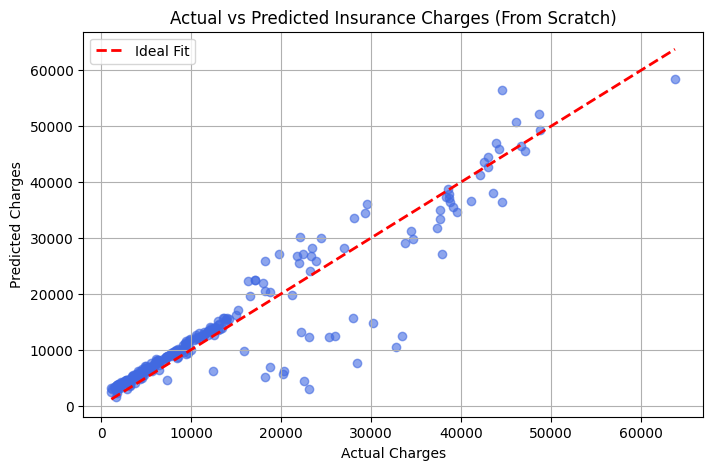

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_test, alpha=0.6, color="royalblue")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Ideal Fit",
)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges (From Scratch)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
k = 5
fold_size = len(X_final) // k
cv_r2_scores = []

for i in range(k):
    val_idx = list(range(i * fold_size, (i + 1) * fold_size))
    tr_idx = [j for j in range(len(X_final)) if j not in val_idx]

    X_tr, y_tr = X_final[tr_idx], y_final[tr_idx]
    X_v, y_v = X_final[val_idx], y_final[val_idx]

    w = np.linalg.pinv(X_tr.T @ X_tr) @ X_tr.T @ y_tr
    y_pred_v = X_v @ w

    r2_v = 1 - (
        np.sum((y_v - y_pred_v) ** 2) / np.sum((y_v - np.mean(y_v)) ** 2)
    )
    cv_r2_scores.append(r2_v)

print(
    f"5-Fold CV Mean R²: {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}"
)

5-Fold CV Mean R²: 0.8400 ± 0.0287


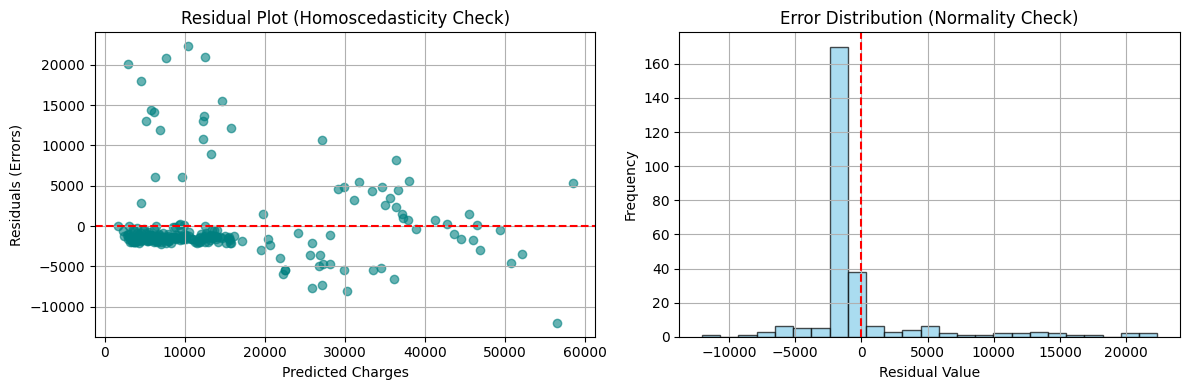

In [ ]:
residuals = y_test - y_pred_test
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals, alpha=0.6, color="teal")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot (Homoscedasticity Check)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=25, edgecolor="black", color="skyblue", alpha=0.7)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title("Error Distribution (Normality Check)")
plt.grid(True)

plt.tight_layout()
plt.show()

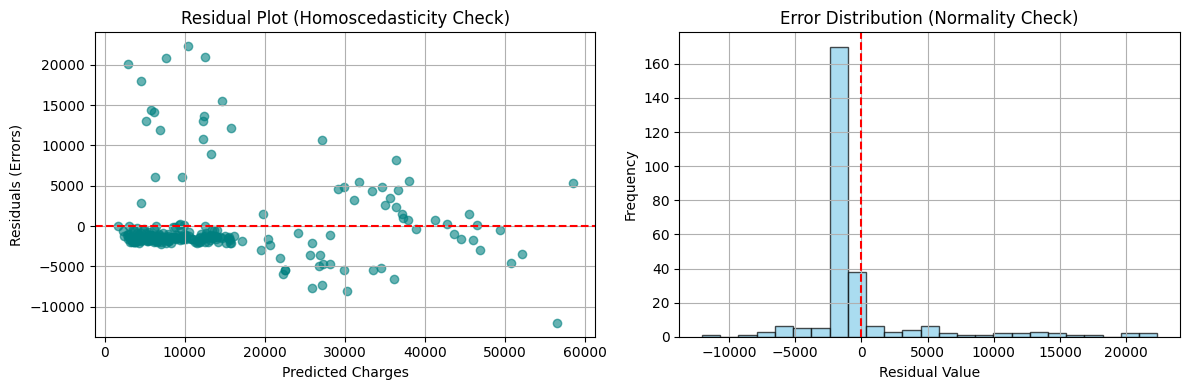

In [ ]:
residuals = y_test - y_pred_test
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals, alpha=0.6, color="teal")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot (Homoscedasticity Check)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=25, edgecolor="black", color="skyblue", alpha=0.7)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title("Error Distribution (Normality Check)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
lambda_param = 1.0
I = np.identity(X_train.shape[1])
I[0, 0] = 0

theta_ridge = (
    np.linalg.inv(X_train.T @ X_train + lambda_param * I)
    @ X_train.T
    @ y_train
)
y_pred_ridge = X_test @ theta_ridge

r2_ridge = 1 - (
    np.sum((y_test - y_pred_ridge) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)
)
print(f"Ridge Regression (λ={lambda_param}) Test R²: {r2_ridge:.4f}")

Ridge Regression (λ=1.0) Test R²: 0.8695
